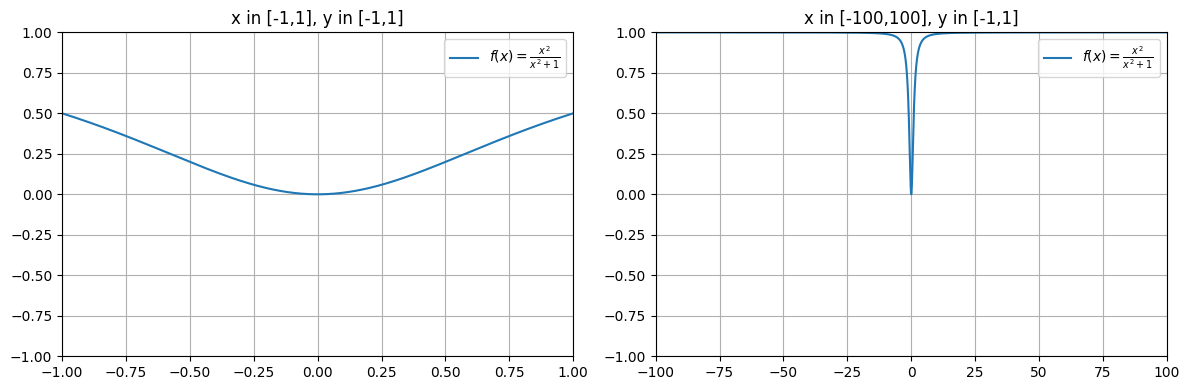

In [1]:
# f(x) = x**2 / (x**2 + 1)

# a.
# Für die Oy-Achse sind Grenzen um [0,1] passend, weil f(x) nur Werte zwischen 0 und 1 annimmt.
# Für die Ox-Achse ist [−1,1] gut, um das Verhalten nahe 0 zu sehen; größere Intervalle wie
# [−10,10] oder [−100,100] zeigen die Annäherung an y=1, machen aber die Krümmung in der Mitte
# schwerer erkennbar.

import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 / (x**2 + 1)

# Daten für kleines Intervall
x1 = np.linspace(-1, 1, 1000)
y1 = f(x1)

# Daten für großes Intervall
x2 = np.linspace(-100, 100, 5000)
y2 = f(x2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1
axes[0].plot(x1, y1, label=r"$f(x)=\frac{x^2}{x^2+1}$")
axes[0].set_xlim(-1, 1)
axes[0].set_ylim(-1, 1)
axes[0].set_title("x in [-1,1], y in [-1,1]")
axes[0].grid(True)
axes[0].legend()

# Plot 2
axes[1].plot(x2, y2, label=r"$f(x)=\frac{x^2}{x^2+1}$")
axes[1].set_xlim(-100, 100)
axes[1].set_ylim(-1, 1)
axes[1].set_title("x in [-100,100], y in [-1,1]")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

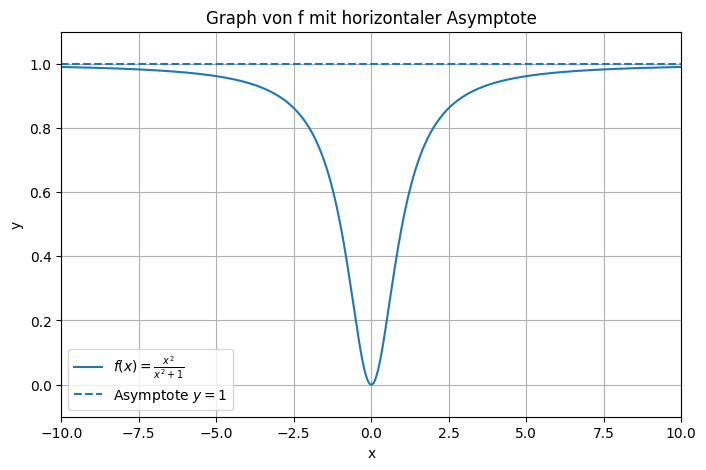

In [2]:
# b.
# Ja, lim x→±∞ x**2 / (x**2 + 1) = 1.
# Damit hat f die horizontale Asymptote y = 1.

x = np.linspace(-10, 10, 1000)
y = f(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, label=r"$f(x)=\frac{x^2}{x^2+1}$")
plt.axhline(1, linestyle="--", label=r"Asymptote $y=1$")
plt.xlim(-10, 10)
plt.ylim(-0.1, 1.1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Graph von f mit horizontaler Asymptote")
plt.grid(True)
plt.legend()
plt.show()

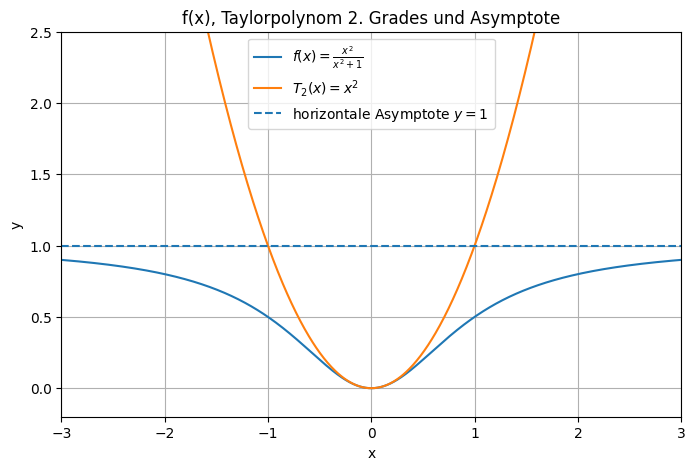

In [3]:
# c.
# T2(x)=f(0)+f′(0)x+(f''(0)/2)x^2
# f(0) = 0
# f'(x) = 2x/(x^2+1)^2 → f'(0) = 0
# f''(x) = 2/(x^2+1)^2 - 8x^2/(x^2+1)^3 → f''(0) = 2
# T2(x) = 0 + 0x + 2/2 x^2 = x^2

def T(x):
    return x**2

x = np.linspace(-3, 3, 1000)

plt.figure(figsize=(8,5))
plt.plot(x, f(x), label=r"$f(x)=\frac{x^2}{x^2+1}$")
plt.plot(x, T(x), label=r"$T_2(x)=x^2$")
plt.axhline(1, linestyle="--", label=r"horizontale Asymptote $y=1$")

plt.xlim(-3, 3)
plt.ylim(-0.2, 2.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("f(x), Taylorpolynom 2. Grades und Asymptote")
plt.grid(True)
plt.legend()
plt.show()

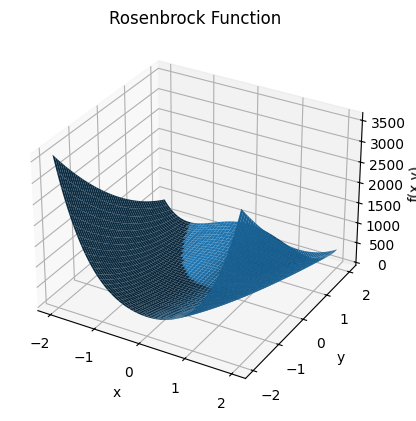

In [24]:
def f(x: float, y: float) -> float:
    return (1 - x)**2 + 100 * (y - x**2)**2

x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
plt.title("Rosenbrock Function")
plt.show()



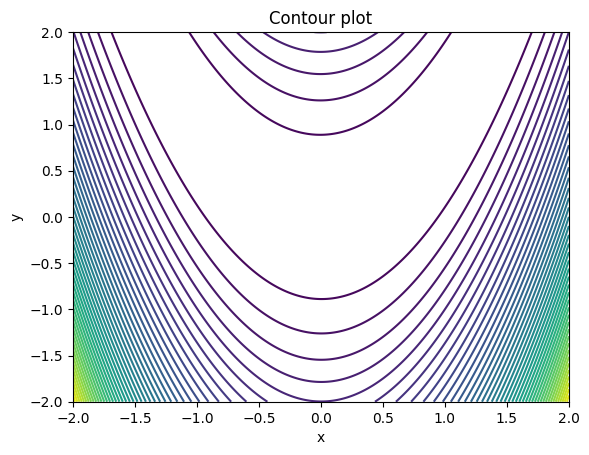

In [16]:
plt.figure()
plt.contour(X, Y, Z, levels=50)
plt.xlabel('x')
plt.ylabel('y')
plt.title("Contour plot")
plt.show()

In [35]:
from scipy.optimize import minimize

def f(v):
    x, y = v
    return (1 - x)**2 + 100 * (y - x**2)**2

start = np.array([-20, 20])

result = minimize(f, start)


print("Minimum point:", result.x)
print("Minimum value:", result.fun)

#Das eigentliche Minimum liegt bei (1,1)
print(f([1, 1]))

Minimum point: [0.99999551 0.99999102]
Minimum value: 2.0150608104507667e-11
0


In [38]:

def hessian(x, y):
    return np.array([[2 - 400*y + 1200*x**2, -400*x],
                     [-400*x,                  200.0]])

x0, y0 = 0.0, 1.0
H = hessian(x0, y0)
eigvals = np.linalg.eigvalsh(H)

print(f"Hesse-Matrix bei (x, y) = ({x0}, {y0}):")
print(H)
print(f"\nEigenwerte: {eigvals}")

Hesse-Matrix bei (x, y) = (0.0, 1.0):
[[-398.   -0.]
 [  -0.  200.]]

Eigenwerte: [-398.  200.]


Die Hessematrix ist nicht uberall positiv semidefinit, also ist diese Funktion nicht konvex.

Die Rosenbrock-Funktion wird häufig als Testfunktion für Optimierungsalgorithmen verwendet, weil ihr globales Minimum in einem langen, schmalen, parabelförmigen und flachen Tal liegt. Die Form des Tals macht es einfach, den allgemeinen Verlauf zu erkennen, doch das exakte Konvergieren zum globalen Minimum gestaltet sich schwierig. Daher eignet sich die Funktion besonders gut, um die Leistungsfähigkeit von Optimierungsverfahren, insbesondere im Hinblick auf Präzision und Konvergenzgeschwindigkeit, zu testen.